<a href="https://colab.research.google.com/github/Indu7777/6thSem-ML-Lab/blob/main/1BM23CS131_LAB4_DECISION-TREE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ZOO ANIMAL CLASSIFICATION USING LOGISTIC REGRESSION

STEP 1: LOADING AND EXPLORING DATASETS

Zoo Dataset Shape: (101, 18)

First 5 rows of zoo dataset:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1  

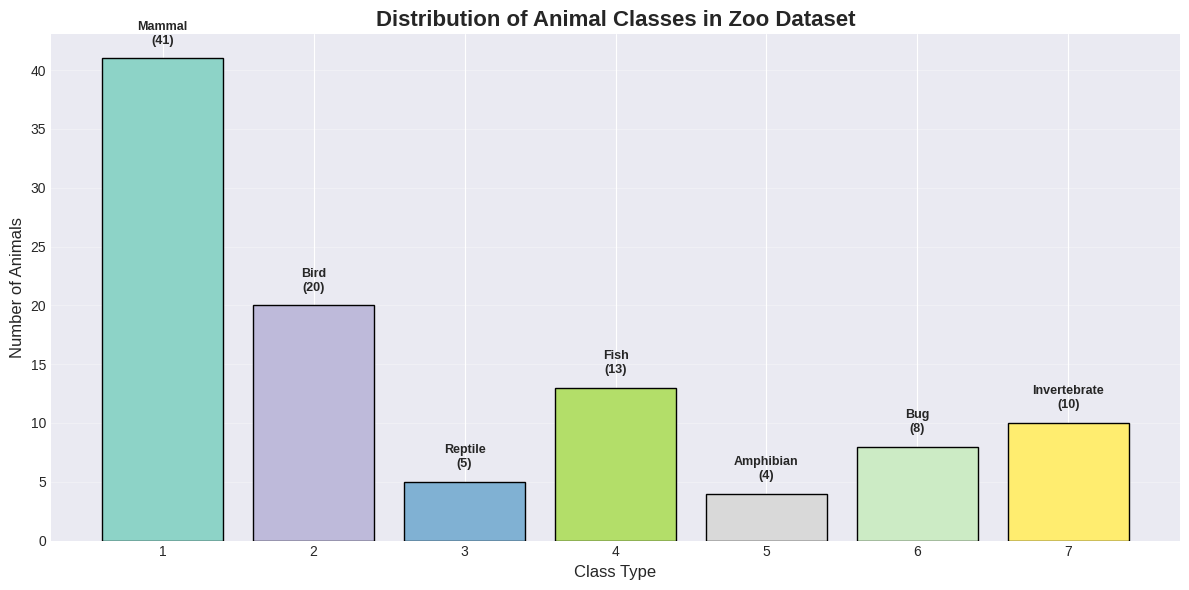


STEP 3: PREPARING FEATURES AND TARGET

Features shape: (101, 16)
Target shape: (101,)

Feature names (16 features):
['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']

Feature statistics (all features are binary):
          hair  feathers      eggs      milk  airborne   aquatic  predator  \
min   0.000000   0.00000  0.000000  0.000000  0.000000  0.000000  0.000000   
max   1.000000   1.00000  1.000000  1.000000  1.000000  1.000000  1.000000   
mean  0.425743   0.19802  0.584158  0.405941  0.237624  0.356436  0.554455   

      toothed  backbone  breathes  venomous      fins      legs      tail  \
min   0.00000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
max   1.00000  1.000000  1.000000  1.000000  1.000000  8.000000  1.000000   
mean  0.60396  0.821782  0.792079  0.079208  0.168317  2.841584  0.742574   

      domestic   catsize  
min   0.000000  0.000

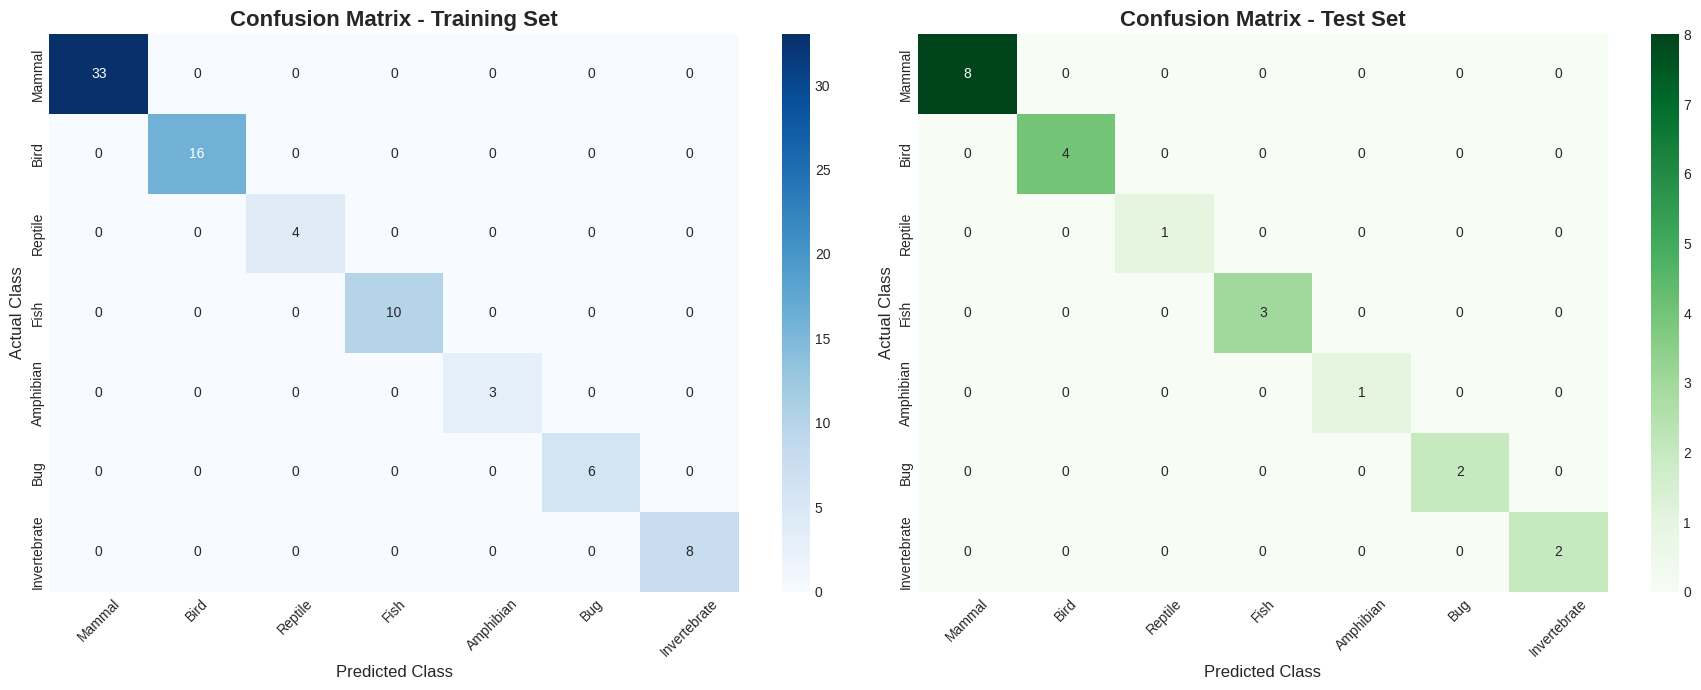

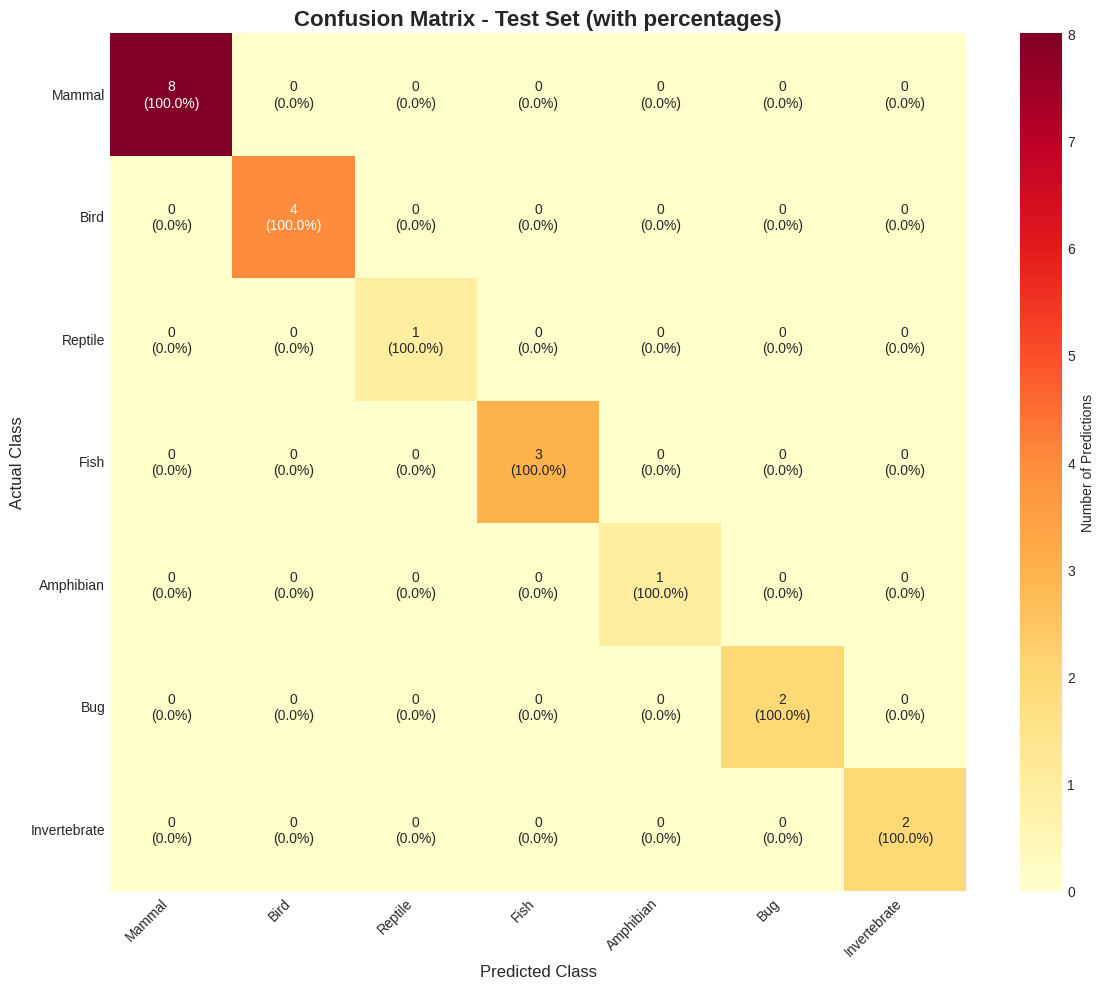


STEP 10: MISCLASSIFICATION ANALYSIS

No misclassifications in test set! Perfect model!

Misclassification by class:

STEP 11: FEATURE IMPORTANCE ANALYSIS

Top 10 most important features for classification:
     feature  importance
8   backbone    0.449779
9   breathes    0.365897
7    toothed    0.358038
1   feathers    0.356622
12      legs    0.339817
13      tail    0.325131
11      fins    0.302771
2       eggs    0.298709
5    aquatic    0.294324
3       milk    0.293617

Bottom 10 least important features:
     feature  importance
11      fins    0.302771
2       eggs    0.298709
5    aquatic    0.294324
3       milk    0.293617
4   airborne    0.264187
0       hair    0.253553
10  venomous    0.182436
15   catsize    0.179488
6   predator    0.167557
14  domestic    0.072811


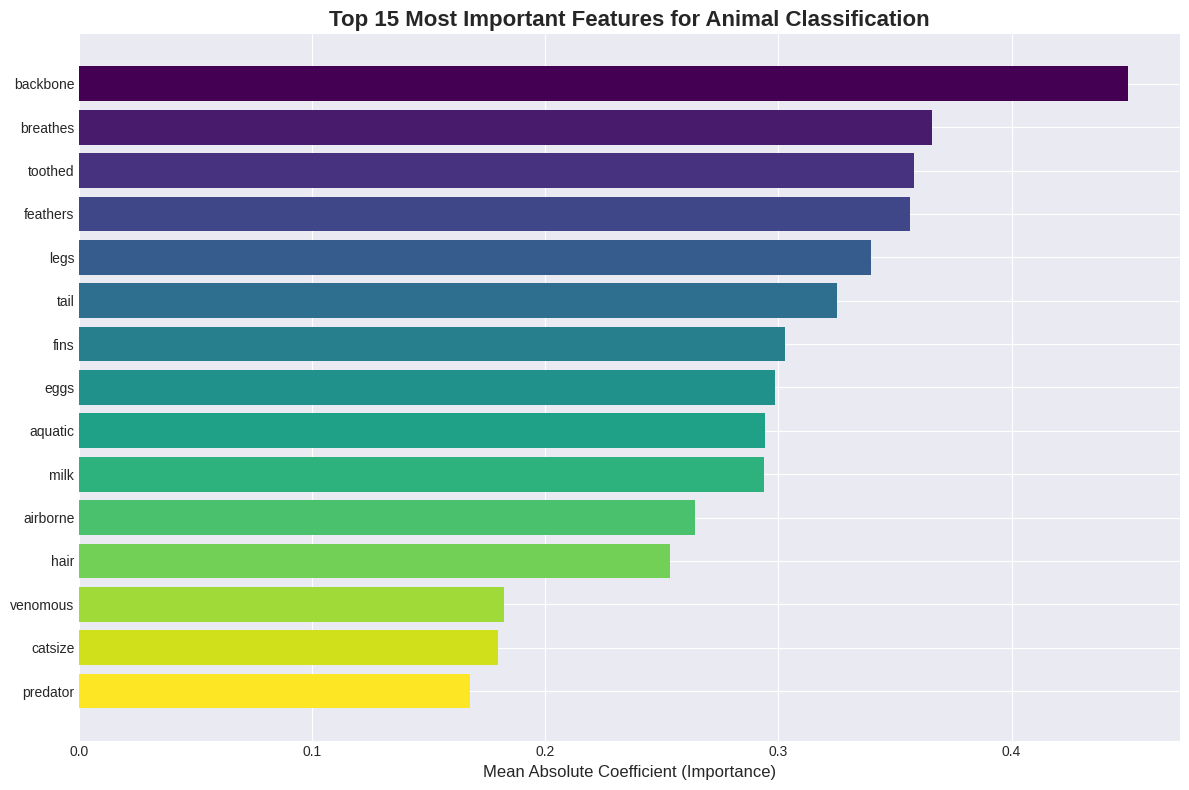


STEP 12: PER-CLASS PERFORMANCE ANALYSIS

Per-Class Performance on Test Set:
 Class   Class Name  Samples  Correct  Precision  Recall  F1-Score
     1       Mammal        8        8        1.0     1.0       1.0
     2         Bird        4        4        1.0     1.0       1.0
     3      Reptile        1        1        1.0     1.0       1.0
     4         Fish        3        3        1.0     1.0       1.0
     5    Amphibian        1        1        1.0     1.0       1.0
     6          Bug        2        2        1.0     1.0       1.0
     7 Invertebrate        2        2        1.0     1.0       1.0


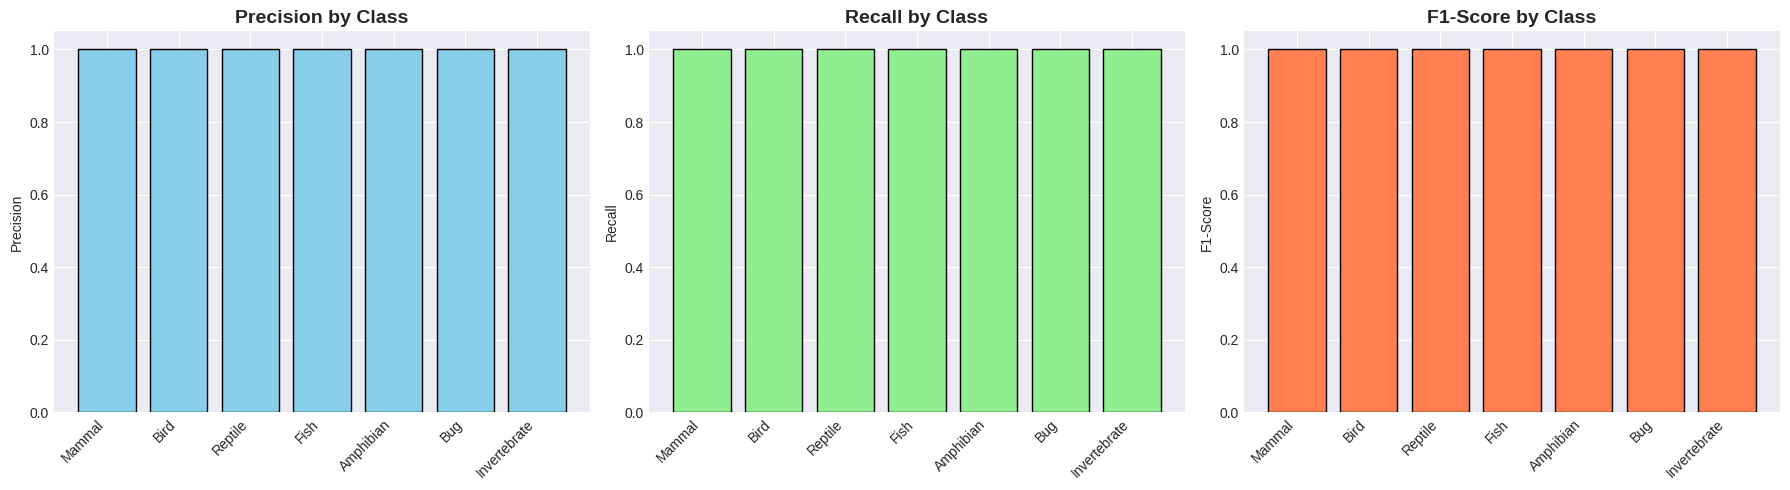


STEP 13: PREDICTION EXAMPLE

Sample Prediction Example:
  Actual Class: 5 (Amphibian)
  Predicted Class: 5 (Amphibian)
  Correct: True

  Prediction Probabilities:
    Mammal: 0.0429 (4.29%)
    Bird: 0.0160 (1.60%)
    Reptile: 0.0550 (5.50%)
    Fish: 0.0258 (2.58%)
    Amphibian: 0.7732 (77.32%)
    Bug: 0.0712 (7.12%)
    Invertebrate: 0.0158 (1.58%)

FINAL SUMMARY - ZOO CLASSIFICATION RESULTS

DATASET SUMMARY:
- Total animals: 101
- Number of features: 16
- Number of classes: 7

CLASS DISTRIBUTION:
  - Mammal: 41 animals (40.6%)
  - Bird: 20 animals (19.8%)
  - Reptile: 5 animals (5.0%)
  - Fish: 13 animals (12.9%)
  - Amphibian: 4 animals (4.0%)
  - Bug: 8 animals (7.9%)
  - Invertebrate: 10 animals (9.9%)

MODEL PERFORMANCE:
- Training Accuracy: 100.00%
- Testing Accuracy:  100.00%
- Cross-validation Mean Accuracy: 93.75% (±3.95%)

BEST PERFORMING CLASSES:
- Highest F1-Score: Mammal (100.00%)

CHALLENGING CLASSES:
- Lowest F1-Score: Mammal (100.00%)

TOP 5 MOST IMPORTANT FEATUR

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("ZOO ANIMAL CLASSIFICATION USING LOGISTIC REGRESSION")
print("="*70)

# ============================================================================
# STEP 1: LOAD AND EXPLORE THE DATASETS
# ============================================================================
print("\n" + "="*70)
print("STEP 1: LOADING AND EXPLORING DATASETS")
print("="*70)

# Load the main zoo data
df_zoo = pd.read_csv('zoo-data.csv')
print(f"\nZoo Dataset Shape: {df_zoo.shape}")
print(f"\nFirst 5 rows of zoo dataset:")
print(df_zoo.head())

# Load the class type information
df_classes = pd.read_csv('zoo-class-type.csv')
print(f"\n" + "="*70)
print("CLASS TYPE INFORMATION")
print("="*70)
print(f"\nClass Types Dataset Shape: {df_classes.shape}")
print("\nClass Type Details:")
print(df_classes[['Class_Number', 'Class_Type', 'Number_Of_Animal_Species_In_Class']])

# Create a class mapping dictionary for reference
class_mapping = dict(zip(df_classes['Class_Number'], df_classes['Class_Type']))
print("\nClass Mapping (Number -> Type):")
for num, name in class_mapping.items():
    print(f"  Class {num}: {name}")

# ============================================================================
# STEP 2: DATA PREPROCESSING
# ============================================================================
print("\n" + "="*70)
print("STEP 2: DATA PREPROCESSING")
print("="*70)

# Check for missing values
print("\nChecking for missing values in zoo dataset:")
missing_values = df_zoo.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found!")

# Check for duplicate rows
duplicates = df_zoo.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Removing duplicate rows...")
    df_zoo = df_zoo.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df_zoo.shape}")

# Check data types
print("\nData types of columns:")
print(df_zoo.dtypes)

# Check unique values in each column (for binary columns)
print("\nUnique values in each column:")
for col in df_zoo.columns:
    if col not in ['animal_name', 'class_type']:
        unique_vals = df_zoo[col].unique()
        print(f"  {col}: {sorted(unique_vals)}")

# Check class distribution
print("\n" + "="*70)
print("CLASS DISTRIBUTION")
print("="*70)
class_dist = df_zoo['class_type'].value_counts().sort_index()
print("\nClass distribution in dataset:")
for class_num, count in class_dist.items():
    class_name = class_mapping.get(class_num, f"Unknown Class {class_num}")
    percentage = (count / len(df_zoo)) * 100
    print(f"  Class {class_num} ({class_name}): {count} animals ({percentage:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(12, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(class_dist)))
bars = plt.bar(class_dist.index, class_dist.values, color=colors, edgecolor='black')

# Add class names on bars
for i, (class_num, count) in enumerate(class_dist.items()):
    class_name = class_mapping.get(class_num, f"Class {class_num}")
    plt.text(class_num, count + 1, f"{class_name}\n({count})",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Distribution of Animal Classes in Zoo Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Class Type', fontsize=12)
plt.ylabel('Number of Animals', fontsize=12)
plt.xticks(class_dist.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('zoo_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# STEP 3: PREPARE FEATURES AND TARGET
# ============================================================================
print("\n" + "="*70)
print("STEP 3: PREPARING FEATURES AND TARGET")
print("="*70)

# Separate features and target
# Drop animal_name as it's not a predictive feature
X = df_zoo.drop(['animal_name', 'class_type'], axis=1)
y = df_zoo['class_type']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names ({len(X.columns)} features):")
print(list(X.columns))

# Check if features need scaling (all are binary 0/1)
print("\nFeature statistics (all features are binary):")
print(X.describe().loc[['min', 'max', 'mean']])

# Since all features are binary (0/1), scaling is NOT necessary
# But we'll keep the scaler for consistency (it won't change binary features much)
print("\nNote: All features are binary (0/1), so scaling is optional.")

# ============================================================================
# STEP 4: SPLIT DATA INTO TRAIN AND TEST SETS
# ============================================================================
print("\n" + "="*70)
print("STEP 4: SPLITTING DATA INTO TRAIN AND TEST SETS")
print("="*70)

# Split the data with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Check class distribution in train and test
print("\nClass distribution in training set:")
train_dist = y_train.value_counts().sort_index()
for class_num, count in train_dist.items():
    class_name = class_mapping.get(class_num, f"Unknown")
    print(f"  Class {class_num} ({class_name}): {count} samples")

print("\nClass distribution in test set:")
test_dist = y_test.value_counts().sort_index()
for class_num, count in test_dist.items():
    class_name = class_mapping.get(class_num, f"Unknown")
    print(f"  Class {class_num} ({class_name}): {count} samples")

# ============================================================================
# STEP 5: APPLY FEATURE SCALING (Optional for binary features)
# ============================================================================
print("\n" + "="*70)
print("STEP 5: FEATURE SCALING")
print("="*70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been scaled using StandardScaler.")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

# ============================================================================
# STEP 6: BUILD LOGISTIC REGRESSION MODEL (MULTICLASS)
# ============================================================================
print("\n" + "="*70)
print("STEP 6: BUILDING MULTICLASS LOGISTIC REGRESSION MODEL")
print("="*70)

# For multiclass classification, we can use:
# 1. 'multinomial' option for softmax regression (preferred)
# 2. OneVsRestClassifier for binary logistic regression

print("\nTraining Logistic Regression with multinomial (softmax) option...")

# Create and train the model
model = LogisticRegression(
    multi_class='multinomial',      # Softmax regression for multiclass
    solver='lbfgs',                 # Solver that supports multinomial
    max_iter=1000,                  # Maximum iterations
    random_state=42,
    C=1.0                           # Regularization strength (1.0 is default)
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

# Get model parameters
print(f"\nNumber of classes: {len(model.classes_)}")
print(f"Classes: {model.classes_}")
print(f"Number of features: {model.coef_.shape[1]}")
print(f"Coefficient matrix shape: {model.coef_.shape}")

# ============================================================================
# STEP 7: MAKE PREDICTIONS AND MEASURE ACCURACY
# ============================================================================
print("\n" + "="*70)
print("STEP 7: MODEL EVALUATION - ACCURACY METRICS")
print("="*70)

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate prediction probabilities
y_train_proba = model.predict_proba(X_train_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n{'='*50}")
print(f"ACCURACY SCORES")
print(f"{'='*50}")
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'='*50}")

# Cross-validation score for more robust evaluation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"\nCross-validation scores (5-fold):")
print(f"  CV Scores: {cv_scores}")
print(f"  Mean CV Accuracy: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"  Std CV Accuracy: {cv_scores.std():.4f}")

# ============================================================================
# STEP 8: DETAILED CLASSIFICATION REPORT
# ============================================================================
print("\n" + "="*70)
print("STEP 8: DETAILED CLASSIFICATION REPORT")
print("="*70)

# Generate classification report with class names
target_names = [class_mapping.get(i, f"Class {i}") for i in sorted(y.unique())]

print("\nClassification Report - Training Set:")
print(classification_report(y_train, y_train_pred, target_names=target_names))

print("\nClassification Report - Test Set:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# ============================================================================
# STEP 9: CONFUSION MATRIX VISUALIZATION
# ============================================================================
print("\n" + "="*70)
print("STEP 9: CONFUSION MATRIX VISUALIZATION")
print("="*70)

# Create confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Training confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix - Training Set', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('Actual Class', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Test confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Predicted Class', fontsize=12)
axes[1].set_ylabel('Actual Class', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('zoo_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# Create a more detailed confusion matrix for test set with percentages
plt.figure(figsize=(12, 10))

# Normalize confusion matrix by row (true class) for percentages
cm_test_percent = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis] * 100

# Create annotation with both count and percentage
annot = np.empty_like(cm_test).astype(str)
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        annot[i, j] = f'{cm_test[i, j]}\n({cm_test_percent[i, j]:.1f}%)'

sns.heatmap(cm_test, annot=annot, fmt='', cmap='YlOrRd',
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={'label': 'Number of Predictions'})
plt.title('Confusion Matrix - Test Set (with percentages)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('zoo_confusion_matrix_detailed.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# STEP 10: ANALYZE MISCLASSIFICATIONS
# ============================================================================
print("\n" + "="*70)
print("STEP 10: MISCLASSIFICATION ANALYSIS")
print("="*70)

# Find indices where predictions are wrong in test set
misclassified_idx = np.where(y_test != y_test_pred)[0]

if len(misclassified_idx) > 0:
    print(f"\nNumber of misclassified samples in test set: {len(misclassified_idx)}")
    print(f"Misclassification rate: {len(misclassified_idx)/len(y_test)*100:.2f}%")

    print("\nMisclassified samples details:")
    print("-" * 80)
    print(f"{'Index':<6} {'Actual Class':<20} {'Predicted Class':<20} {'Animal Name':<20}")
    print("-" * 80)

    for idx in misclassified_idx[:10]:  # Show first 10 misclassifications
        actual = y_test.iloc[idx]
        predicted = y_test_pred[idx]
        actual_name = class_mapping.get(actual, f"Class {actual}")
        predicted_name = class_mapping.get(predicted, f"Class {predicted}")

        # Get animal name from original dataframe using the index
        # Note: Need to map back to original index
        original_idx = y_test.index[idx]
        animal_name = df_zoo.loc[original_idx, 'animal_name']

        print(f"{original_idx:<6} {actual_name:<20} {predicted_name:<20} {animal_name:<20}")

    if len(misclassified_idx) > 10:
        print(f"... and {len(misclassified_idx) - 10} more")
else:
    print("\nNo misclassifications in test set! Perfect model!")

# Analyze which classes are most confused
print("\nMisclassification by class:")
misclass_by_class = pd.crosstab(y_test, y_test_pred,
                                 rownames=['Actual'],
                                 colnames=['Predicted'])

# Show only where actual != predicted (off-diagonal)
for actual in misclass_by_class.index:
    for predicted in misclass_by_class.columns:
        if actual != predicted and misclass_by_class.loc[actual, predicted] > 0:
            count = misclass_by_class.loc[actual, predicted]
            actual_name = class_mapping.get(actual, f"Class {actual}")
            predicted_name = class_mapping.get(predicted, f"Class {predicted}")
            print(f"  {actual_name} misclassified as {predicted_name}: {count} time(s)")

# ============================================================================
# STEP 11: FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("STEP 11: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# For multiclass logistic regression, we have coefficients for each class
# Calculate overall feature importance as the mean absolute coefficient across classes
feature_importance = np.mean(np.abs(model.coef_), axis=0)

# Create dataframe of feature importance
feature_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features for classification:")
print(feature_imp_df.head(10))

print("\nBottom 10 least important features:")
print(feature_imp_df.tail(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_imp_df.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Mean Absolute Coefficient (Importance)', fontsize=12)
plt.title('Top 15 Most Important Features for Animal Classification', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('zoo_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# STEP 12: PER-CLASS PERFORMANCE ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("STEP 12: PER-CLASS PERFORMANCE ANALYSIS")
print("="*70)

# Calculate per-class metrics from confusion matrix
class_performance = []
for i, class_num in enumerate(sorted(y.unique())):
    class_name = class_mapping.get(class_num, f"Class {class_num}")

    # True positives, false positives, false negatives for this class
    tp = cm_test[i, i]
    fn = cm_test[i, :].sum() - tp
    fp = cm_test[:, i].sum() - tp

    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    class_performance.append({
        'Class': class_num,
        'Class Name': class_name,
        'Samples': cm_test[i, :].sum(),
        'Correct': tp,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

perf_df = pd.DataFrame(class_performance)
print("\nPer-Class Performance on Test Set:")
print(perf_df.to_string(index=False))

# Visualize per-class performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision by class
axes[0].bar(range(len(perf_df)), perf_df['Precision'], color='skyblue', edgecolor='black')
axes[0].set_xticks(range(len(perf_df)))
axes[0].set_xticklabels(perf_df['Class Name'], rotation=45, ha='right')
axes[0].set_title('Precision by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Precision')
axes[0].set_ylim([0, 1.05])

# Recall by class
axes[1].bar(range(len(perf_df)), perf_df['Recall'], color='lightgreen', edgecolor='black')
axes[1].set_xticks(range(len(perf_df)))
axes[1].set_xticklabels(perf_df['Class Name'], rotation=45, ha='right')
axes[1].set_title('Recall by Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall')
axes[1].set_ylim([0, 1.05])

# F1-Score by class
axes[2].bar(range(len(perf_df)), perf_df['F1-Score'], color='coral', edgecolor='black')
axes[2].set_xticks(range(len(perf_df)))
axes[2].set_xticklabels(perf_df['Class Name'], rotation=45, ha='right')
axes[2].set_title('F1-Score by Class', fontsize=14, fontweight='bold')
axes[2].set_ylabel('F1-Score')
axes[2].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('zoo_per_class_performance.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# STEP 13: PREDICTION EXAMPLE
# ============================================================================
print("\n" + "="*70)
print("STEP 13: PREDICTION EXAMPLE")
print("="*70)

# Take a random sample from test set for demonstration
sample_idx = 0
sample_actual = y_test.iloc[sample_idx]
sample_pred = y_test_pred[sample_idx]
sample_proba = y_test_proba[sample_idx]

actual_name = class_mapping.get(sample_actual, f"Class {sample_actual}")
pred_name = class_mapping.get(sample_pred, f"Class {sample_pred}")

print(f"\nSample Prediction Example:")
print(f"  Actual Class: {sample_actual} ({actual_name})")
print(f"  Predicted Class: {sample_pred} ({pred_name})")
print(f"  Correct: {sample_actual == sample_pred}")

print(f"\n  Prediction Probabilities:")
for i, prob in enumerate(sample_proba):
    class_name = class_mapping.get(model.classes_[i], f"Class {model.classes_[i]}")
    print(f"    {class_name}: {prob:.4f} ({prob*100:.2f}%)")

# ============================================================================
# STEP 14: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("FINAL SUMMARY - ZOO CLASSIFICATION RESULTS")
print("="*70)

print(f"""
DATASET SUMMARY:
- Total animals: {len(df_zoo)}
- Number of features: {X.shape[1]}
- Number of classes: {len(df_classes)}

CLASS DISTRIBUTION:
{chr(10).join([f"  - {class_mapping[c]}: {count} animals ({count/len(df_zoo)*100:.1f}%)" for c, count in class_dist.items()])}

MODEL PERFORMANCE:
- Training Accuracy: {train_accuracy:.2%}
- Testing Accuracy:  {test_accuracy:.2%}
- Cross-validation Mean Accuracy: {cv_scores.mean():.2%} (±{cv_scores.std():.2%})

BEST PERFORMING CLASSES:
- Highest F1-Score: {perf_df.loc[perf_df['F1-Score'].idxmax(), 'Class Name']} ({perf_df['F1-Score'].max():.2%})

CHALLENGING CLASSES:
- Lowest F1-Score: {perf_df.loc[perf_df['F1-Score'].idxmin(), 'Class Name']} ({perf_df['F1-Score'].min():.2%})

TOP 5 MOST IMPORTANT FEATURES:
{chr(10).join([f"  {i+1}. {row['feature']} (importance: {row['importance']:.4f})"
               for i, (_, row) in enumerate(feature_imp_df.head(5).iterrows())])}

CONCLUSION:
The logistic regression model achieves {test_accuracy:.2%} accuracy on the test set,
which is {'excellent' if test_accuracy > 0.95 else 'very good' if test_accuracy > 0.9 else 'good'}
for this multiclass classification problem with {len(df_classes)} classes.
""")

# Save the model results to a file
with open('zoo_model_results.txt', 'w') as f:
    f.write("ZOO DATASET CLASSIFICATION RESULTS\n")
    f.write("="*50 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Training Accuracy: {train_accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_test_pred, target_names=target_names))

print("\nResults have been saved to 'zoo_model_results.txt'")